# VEHMS Predictive Maintenance - Original Dataset Analysis (cars1.csv)

## Overview
This notebook analyzes the **original dataset** from existing research papers for Vehicle Engine Health Monitoring System (VEHMS).

### Dataset Characteristics
- **Source**: cars1.csv (Original research dataset)
- **Features**: 6 sensor readings (Crankshaft, Overheating, Lubricant, Misfires, Piston, Starter)
- **Target**: Decision (Good, Minor, Moderate, Critical)

### Analysis Scope
1. **Individual Base Classifiers** (10 classifiers)
2. **Existing Research Stacked Ensembles** (ER-Stacked Models 1, 2, 3)
3. **Dynamic Classifier Selection** (Performance, Diversity, Combined, Greedy)

**Note**: CNN-LSTM deep learning techniques are excluded as per requirements.

---
## Phase 1: Environment Setup and Data Loading

In [30]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
np.random.seed(42)

print('Libraries imported successfully!')

Libraries imported successfully!


In [31]:
# Import VEHMS modules
from vehms.data_preprocessor import DataPreprocessor
from vehms.base_classifier_module import BaseClassifierModule
from vehms.model_evaluator import ModelEvaluator
from vehms.existing_research_stacked_ensemble import ExistingResearchStackedEnsemble
from vehms.dynamic_classifier_selector import DynamicClassifierSelector
from vehms.performance_visualizer import PerformanceVisualizer
from vehms.xai_explainer import XAIExplainer
from vehms.config import RANDOM_SEED

print('VEHMS modules imported successfully!')

VEHMS modules imported successfully!


In [32]:
# Load the original dataset
print('='*60)
print('LOADING ORIGINAL DATASET (cars1.csv)')
print('='*60)

df = pd.read_csv('dataset/cars1.csv')

print(f'\nDataset Shape: {df.shape}')
print(f'Total Samples: {df.shape[0]:,}')
print(f'Total Features: {df.shape[1] - 1}')
print(f'\nColumns: {df.columns.tolist()}')

LOADING ORIGINAL DATASET (cars1.csv)

Dataset Shape: (3003, 7)
Total Samples: 3,003
Total Features: 6

Columns: ['Crankshaft', 'Overheating', 'Lubricant', 'Misfires', 'Piston', 'Starter', 'Decision']


In [33]:
# Display first few rows
print('\nFirst 10 rows of the dataset:')
df.head(10)


First 10 rows of the dataset:


,Crankshaft,Overheating,Lubricant,Misfires,Piston,Starter,Decision
0,8.296,12.333,10.242,4.778,8.140,377.835,Minor
1,817.231,15.070,1249.033,4.843,7.806,3.778,Critical
2,7.354,11.929,12.492,3.232,717.916,3.382,Moderate
3,9.387,11.499,12.459,4.164,8.301,437.046,Moderate
4,8.052,14.746,11.962,5.337,7.055,483.639,Moderate
5,7.661,14.125,1331.180,4.654,8.573,3.475,Critical
6,7.486,11.741,11.730,4.749,8.540,345.849,Minor
7,8.565,15.154,10.917,5.087,995.690,432.335,Critical
8,9.790,12.599,12.109,523.138,8.100,371.332,Critical
9,8.456,14.176,10.603,4.564,8.124,437.677,Moderate


In [34]:
# Dataset info and statistics
print('\nDataset Information:')
print('-'*40)
df.info()
print('\nStatistical Summary:')
df.describe()


Dataset Information:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3003 entries, 0 to 3002
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Crankshaft   3003 non-null   float64
 1   Overheating  3003 non-null   float64
 2   Lubricant    3003 non-null   float64
 3   Misfires     3003 non-null   float64
 4   Piston       3003 non-null   float64
 5   Starter      3003 non-null   float64
 6   Decision     3003 non-null   object 
dtypes: float64(6), object(1)
memory usage: 164.4+ KB

Statistical Summary:


,Crankshaft,Overheating,Lubricant,Misfires,Piston,Starter
count,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000,3003.000000
mean,28.708148,65.002237,147.924402,71.428585,61.092805,197.121763
std,130.746314,256.503955,384.436259,167.963627,205.593981,210.143244
min,6.105000,9.120000,8.612000,2.902000,6.045000,2.465000
25%,8.073000,12.066000,11.215500,4.453000,7.907000,4.102000
50%,8.754000,13.042000,12.313000,4.979000,8.594000,5.155000
75%,9.499000,14.147000,13.611000,5.672500,9.407000,410.832000
max,1113.196000,1683.831000,1617.447000,688.844000,1068.133000,590.698000


In [35]:
# Check for missing values
print('\nMissing Values Check:')
print('-'*40)
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')


Missing Values Check:
----------------------------------------
Crankshaft     0
Overheating    0
Lubricant      0
Misfires       0
Piston         0
Starter        0
Decision       0
dtype: int64

Total missing values: 0



Target Variable Distribution:
----------------------------------------
Decision
Good        947
Critical    710
Moderate    677
Minor       669
Name: count, dtype: int64


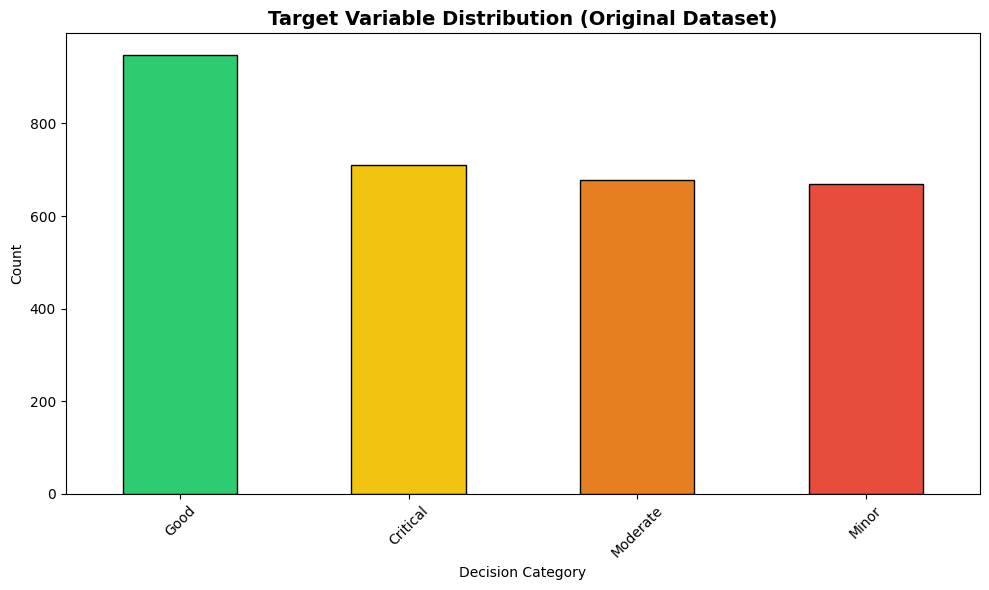

In [36]:
# Target distribution
print('\nTarget Variable Distribution:')
print('-'*40)
target_dist = df['Decision'].value_counts()
print(target_dist)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
target_dist.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Target Variable Distribution (Original Dataset)', fontsize=14, fontweight='bold')
plt.xlabel('Decision Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## Phase 2: Data Preprocessing

In [37]:
# Initialize preprocessor
preprocessor = DataPreprocessor(test_size=0.2, random_state=RANDOM_SEED)

# Separate features and target
X, y = preprocessor.separate_features_target(df, target='Decision')

FEATURE-TARGET SEPARATION

[OK] Features (X): 6 columns
   Columns: Crankshaft, Overheating, Lubricant, Misfires, Piston, Starter

[OK] Target (y): 'Decision' column
   Unique values: ['Minor', 'Critical', 'Moderate', 'Good']


In [38]:
# Scale features
X_scaled = preprocessor.fit_transform_features(X)

# Encode target
y_encoded = preprocessor.encode_target(y)


FEATURE SCALING (StandardScaler)

[OK] StandardScaler fitted and applied to 6 features

[OK] All features now have mean ~ 0 and std ~ 1

TARGET ENCODING (LabelEncoder)

[OK] LabelEncoder fitted and applied to target variable

   Label Encoding Mapping:
----------------------------------------
   Critical   -> 0  (710 samples, 23.6%)
   Good       -> 1  (947 samples, 31.5%)
   Minor      -> 2  (669 samples, 22.3%)
   Moderate   -> 3  (677 samples, 22.5%)


In [39]:
# Train-test split
X_train, X_test, y_train, y_test = preprocessor.train_test_split(X_scaled, y_encoded)

print(f'\nFinal shapes:')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')


TRAIN-TEST SPLIT (Stratified Sampling)

[OK] Data split with stratified sampling
   Random state: 42
   Test size: 20%

   Training Set:
   - X_train shape: (2402, 6)
   - y_train shape: (2402,)

   Testing Set:
   - X_test shape: (601, 6)
   - y_test shape: (601,)

   Class Distribution Verification:
--------------------------------------------------
   Class           Train       Test      Total
--------------------------------------------------
   Critical      568 (23.6%)   142 (23.6%)    710
   Good          757 (31.5%)   190 (31.6%)    947
   Minor         535 (22.3%)   134 (22.3%)    669
   Moderate      542 (22.6%)   135 (22.5%)    677
--------------------------------------------------

Final shapes:
X_train: (2402, 6), y_train: (2402,)
X_test: (601, 6), y_test: (601,)


---
## Phase 3: Individual Base Classifiers Training

In [40]:
# Initialize base classifier module
base_clf = BaseClassifierModule(random_state=RANDOM_SEED)

# Train all base classifiers
base_results_df = base_clf.train_all(X_train, y_train, X_test, y_test)

print('\n' + '='*60)
print('BASE CLASSIFIER RESULTS SUMMARY')
print('='*60)
base_results_df

BASE CLASSIFIER MODULE INITIALIZED

Random State: 42

Available Classifiers: 10
--------------------------------------------------
   1. LR
   2. KNN
   3. LDA
   4. GNB
   5. SVM
   6. DT
   7. RF
   8. AdaBoost
   9. GB
  10. XGBoost
--------------------------------------------------

TRAINING ALL BASE CLASSIFIERS

Training samples: 2,402
Features: 6
Testing samples: 601

[...] Training LR classifier...
[OK] LR trained successfully!
   Training Time: 0.00 seconds
   Training Accuracy: 0.7731 (77.31%)
   Testing Accuracy:  0.7937 (79.37%)

[...] Training KNN classifier...
[OK] KNN trained successfully!
   Training Time: 0.00 seconds
   Training Accuracy: 0.9301 (93.01%)
   Testing Accuracy:  0.9434 (94.34%)

[...] Training LDA classifier...
[OK] LDA trained successfully!
   Training Time: 0.00 seconds
   Training Accuracy: 0.7577 (75.77%)
   Testing Accuracy:  0.7720 (77.20%)

[...] Training GNB classifier...
[OK] GNB trained successfully!
   Training Time: 0.00 seconds
   Training Ac

,Classifier,Train Accuracy,Test Accuracy,Training Time (s)
0,KNN,0.930058,0.943428,0.000598
1,SVM,0.910908,0.935108,0.091734
2,RF,1.000000,0.935108,0.234087
3,GB,0.942132,0.921797,0.771682
4,XGBoost,1.000000,0.915141,0.952588
5,DT,1.000000,0.863561,0.009766
6,AdaBoost,0.828476,0.828619,0.140462
7,LR,0.773106,0.793677,0.004665
8,LDA,0.757702,0.772047,0.000807
9,GNB,0.672356,0.683860,0.000514


In [41]:
# Evaluate all base classifiers
evaluator = ModelEvaluator()

base_metrics = {}
for name in base_clf.trained_models.keys():
    model = base_clf.get_classifier(name)
    metrics = evaluator.evaluate_model(model, X_test, y_test, model_name=name)
    base_metrics[name] = metrics

# Display comparison
base_comparison_df = evaluator.compare_models()
print('\nBase Classifier Performance Comparison:')
base_comparison_df


Base Classifier Performance Comparison:


,Model,RMSE,RMSD,MAE,Accuracy,Precision,AUC
0,RF,0.463295,0.463295,0.108153,0.935108,0.937129,0.969640
1,GB,0.551808,0.551808,0.141431,0.921797,0.923205,0.969117
2,SVM,0.411967,0.411967,0.096506,0.935108,0.936830,0.968461
3,XGBoost,0.562263,0.562263,0.149750,0.915141,0.916841,0.966040
4,KNN,0.378279,0.378279,0.083195,0.943428,0.945731,0.963387
5,LR,0.756558,0.756558,0.302829,0.793677,0.796425,0.945830
6,AdaBoost,0.785687,0.785687,0.297837,0.828619,0.842753,0.944208
7,LDA,0.875817,0.875817,0.367720,0.772047,0.762018,0.910675
8,GNB,0.962699,0.962699,0.474210,0.683860,0.828220,0.910172
9,DT,0.592521,0.592521,0.204659,0.863561,0.864396,0.908948


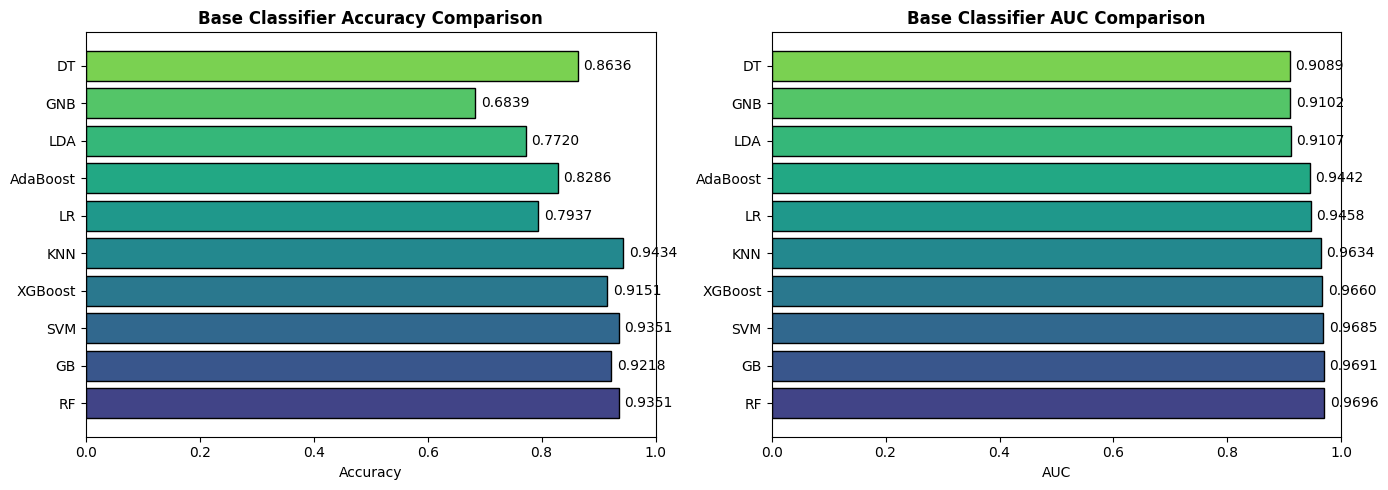

In [42]:
# Visualize base classifier performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1 = axes[0]
models = base_comparison_df['Model'].tolist()
accuracies = base_comparison_df['Accuracy'].tolist()
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(models)))
bars = ax1.barh(models, accuracies, color=colors, edgecolor='black')
ax1.set_xlabel('Accuracy')
ax1.set_title('Base Classifier Accuracy Comparison', fontweight='bold')
ax1.set_xlim(0, 1)
for bar, acc in zip(bars, accuracies):
    ax1.text(acc + 0.01, bar.get_y() + bar.get_height()/2, f'{acc:.4f}', va='center')

# AUC comparison
ax2 = axes[1]
aucs = base_comparison_df['AUC'].tolist()
bars = ax2.barh(models, aucs, color=colors, edgecolor='black')
ax2.set_xlabel('AUC')
ax2.set_title('Base Classifier AUC Comparison', fontweight='bold')
ax2.set_xlim(0, 1)
for bar, auc in zip(bars, aucs):
    ax2.text(auc + 0.01, bar.get_y() + bar.get_height()/2, f'{auc:.4f}', va='center')

plt.tight_layout()
plt.show()

---
## Phase 4: Existing Research Stacked Ensemble Models

In [43]:
# Initialize existing research stacked ensemble
er_ensemble = ExistingResearchStackedEnsemble(cv=5, random_state=RANDOM_SEED)

print('='*70)
print('EXISTING RESEARCH STACKED ENSEMBLE CONFIGURATIONS')
print('='*70)
print('\nER-Stacked Model 1: RF + SVM + GB + DT + KNN')
print('ER-Stacked Model 2: LR + SVM + LDA + GB + AdaBoost')
print('ER-Stacked Model 3: LR + KNN + SVM + LDA + GB + AdaBoost + DT + RF + GNB (All 9)')

EXISTING RESEARCH STACKED ENSEMBLE CONFIGURATIONS

ER-Stacked Model 1: RF + SVM + GB + DT + KNN
ER-Stacked Model 2: LR + SVM + LDA + GB + AdaBoost
ER-Stacked Model 3: LR + KNN + SVM + LDA + GB + AdaBoost + DT + RF + GNB (All 9)


In [44]:
# Create and train ER-Stacked Model 1
er_model_1 = er_ensemble.create_er_stacked_model_1()
er_ensemble.train_stacked_model('ER-Stacked Model 1', er_model_1, X_train, y_train)
er_ensemble.display_architecture('ER-Stacked Model 1')


[...] Training ER-Stacked Model 1...
   Base estimators: ['rf', 'svm', 'gb', 'dt', 'knn']
   Meta-learner: LogisticRegression
   Cross-validation folds: 5

[OK] ER-Stacked Model 1 trained successfully!
   Training time: 3.30 seconds
   Training accuracy: 0.9313 (93.13%)

ARCHITECTURE: ER-Stacked Model 1

                    +----------------------------+
                    |    Input Features (9)     |
                    +----------------------------+
                                 |
                                 v

     +------------------------------------------------------------+
     |               Level 0: Base Classifiers                    |
     |------------------------------------------------------------|
     |  [  RF  ] [ SVM  ] [  GB  ] [  DT  ] [ KNN  ]                  |
     +------------------------------------------------------------+
                                 |
                                 v

               +--------------------------------------+

In [45]:
# Create and train ER-Stacked Model 2
er_model_2 = er_ensemble.create_er_stacked_model_2()
er_ensemble.train_stacked_model('ER-Stacked Model 2', er_model_2, X_train, y_train)
er_ensemble.display_architecture('ER-Stacked Model 2')


[...] Training ER-Stacked Model 2...
   Base estimators: ['lr', 'svm', 'lda', 'gb', 'ada']
   Meta-learner: LogisticRegression
   Cross-validation folds: 5

[OK] ER-Stacked Model 2 trained successfully!
   Training time: 1.98 seconds
   Training accuracy: 0.9313 (93.13%)

ARCHITECTURE: ER-Stacked Model 2

                    +----------------------------+
                    |    Input Features (9)     |
                    +----------------------------+
                                 |
                                 v

     +------------------------------------------------------------+
     |               Level 0: Base Classifiers                    |
     |------------------------------------------------------------|
     |  [  LR  ] [ SVM  ] [ LDA  ] [  GB  ] [ ADA  ]                  |
     +------------------------------------------------------------+
                                 |
                                 v

               +--------------------------------------

In [46]:
# Create and train ER-Stacked Model 3
er_model_3 = er_ensemble.create_er_stacked_model_3()
er_ensemble.train_stacked_model('ER-Stacked Model 3', er_model_3, X_train, y_train)
er_ensemble.display_architecture('ER-Stacked Model 3')


[...] Training ER-Stacked Model 3...
   Base estimators: ['lr', 'knn', 'svm', 'lda', 'gb', 'ada', 'dt', 'rf', 'gnb']
   Meta-learner: LogisticRegression
   Cross-validation folds: 5

[OK] ER-Stacked Model 3 trained successfully!
   Training time: 2.82 seconds
   Training accuracy: 0.9313 (93.13%)

ARCHITECTURE: ER-Stacked Model 3

                    +----------------------------+
                    |    Input Features (9)     |
                    +----------------------------+
                                 |
                                 v

     +------------------------------------------------------------+
     |               Level 0: Base Classifiers                    |
     |------------------------------------------------------------|
     |  [  LR  ] [ KNN  ] [ SVM  ] [ LDA  ] [  GB  ] [ ADA  ] [  DT  ] [  RF  ] [ GNB  ] |
     +------------------------------------------------------------+
                                 |
                                 v

         

In [47]:
# Evaluate all ER-Stacked models
er_evaluator = ModelEvaluator()

er_models = er_ensemble.get_all_models()
for name, model in er_models.items():
    er_evaluator.evaluate_model(model, X_test, y_test, model_name=name)

# Display comparison
er_comparison_df = er_evaluator.compare_models()
print('\nExisting Research Stacked Model Performance:')
er_comparison_df


Existing Research Stacked Model Performance:


,Model,RMSE,RMSD,MAE,Accuracy,Precision,AUC
0,ER-Stacked Model 3,0.382652,0.382652,0.083195,0.945092,0.947568,0.972538
1,ER-Stacked Model 1,0.382652,0.382652,0.083195,0.945092,0.947568,0.972266
2,ER-Stacked Model 2,0.399667,0.399667,0.086522,0.945092,0.947539,0.971554


---
## Phase 5: Dynamic Classifier Selection

In [48]:
# Initialize dynamic classifier selector
dcs = DynamicClassifierSelector(cv=5, random_state=RANDOM_SEED)

print('='*70)
print('DYNAMIC CLASSIFIER SELECTION')
print('='*70)
print('\nSelection Methods:')
print('1. Performance-Based: Select top-k by individual accuracy')
print('2. Diversity-Based: Maximize ensemble diversity using Q-statistic')
print('3. Combined: Balance performance (60%) + diversity (40%)')
print('4. Greedy Forward: Iteratively add classifiers that improve ensemble')

DYNAMIC CLASSIFIER SELECTION

Selection Methods:
1. Performance-Based: Select top-k by individual accuracy
2. Diversity-Based: Maximize ensemble diversity using Q-statistic
3. Combined: Balance performance (60%) + diversity (40%)
4. Greedy Forward: Iteratively add classifiers that improve ensemble


[...] Fitting all classifiers...
   LR: 0.7937
   KNN: 0.9434
   LDA: 0.7720
   GNB: 0.6839
   SVM: 0.9351
   DT: 0.8636
   RF: 0.9351
   AdaBoost: 0.8286
   GB: 0.9218
   XGBoost: 0.9151

[CHART] Individual Classifier Performance (Ranked):
--------------------------------------------------
    1. KNN        0.9434 |***********************************************
    2. SVM        0.9351 |**********************************************
    3. RF         0.9351 |**********************************************
    4. GB         0.9218 |**********************************************
    5. XGBoost    0.9151 |*********************************************
    6. DT         0.8636 |*******************************************
    7. AdaBoost   0.8286 |*****************************************
    8. LR         0.7937 |***************************************
    9. LDA        0.7720 |**************************************
   10. GNB        0.6839 |**********************************

[OK] All 10 

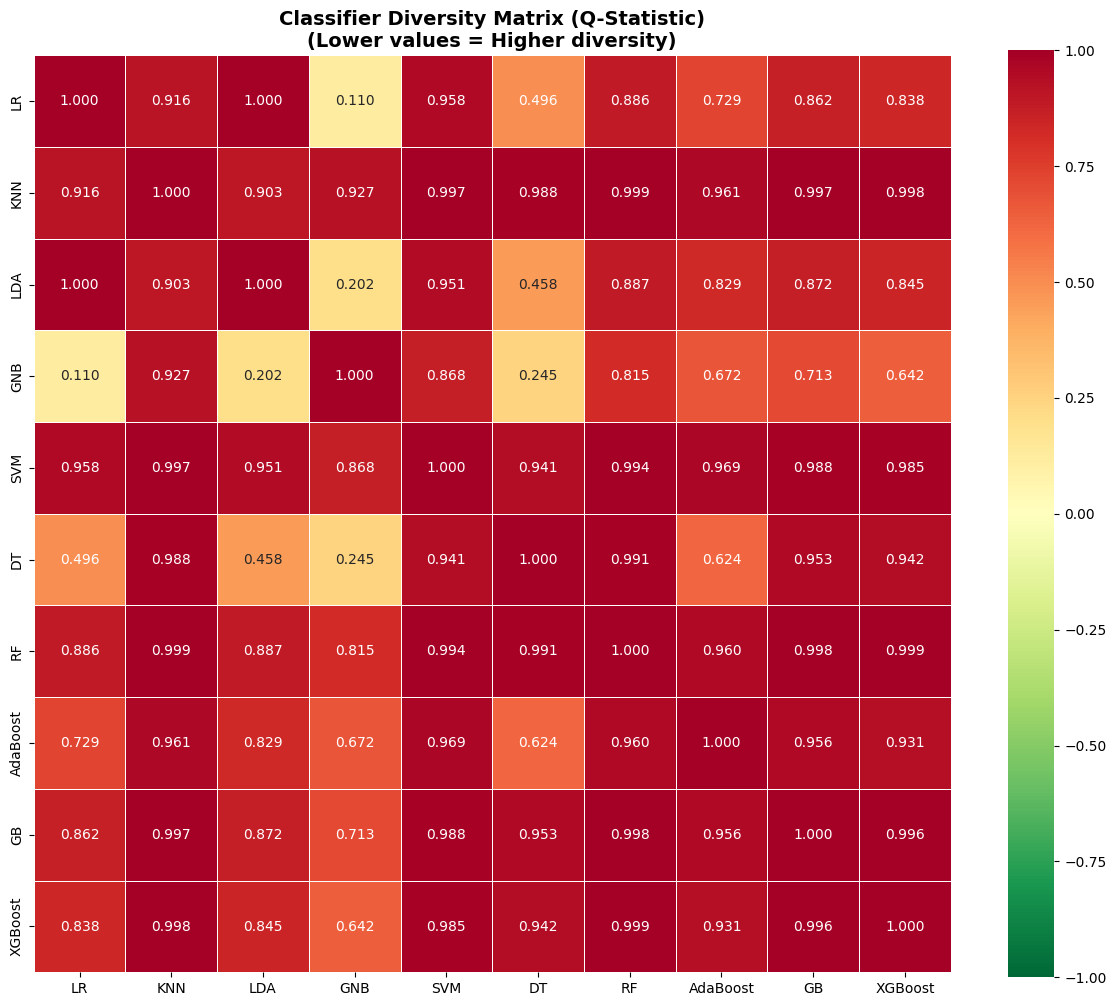

In [49]:
# Run all selection methods
selection_results = dcs.run_all_selection_methods(
    X_train, y_train, X_test, y_test, top_k=5
)

In [50]:
# Create and train dynamic stacks
dynamic_stacks = {}
dynamic_evaluator = ModelEvaluator()

# Performance-based stack
print('\n' + '='*60)
print('Training Dynamic Stacks...')
print('='*60)

perf_stack = dcs.create_dynamic_stack(selection_results['performance'])
perf_stack.fit(X_train, y_train)
dynamic_stacks['DS-Performance'] = perf_stack
print(f"\nDS-Performance trained with: {selection_results['performance']}")

# Diversity-based stack
div_stack = dcs.create_dynamic_stack(selection_results['diversity'])
div_stack.fit(X_train, y_train)
dynamic_stacks['DS-Diversity'] = div_stack
print(f"DS-Diversity trained with: {selection_results['diversity']}")

# Combined stack
comb_stack = dcs.create_dynamic_stack(selection_results['combined'])
comb_stack.fit(X_train, y_train)
dynamic_stacks['DS-Combined'] = comb_stack
print(f"DS-Combined trained with: {selection_results['combined']}")


Training Dynamic Stacks...

DS-Performance trained with: ['KNN', 'SVM', 'RF', 'GB', 'XGBoost']
DS-Diversity trained with: ['KNN', 'LDA', 'GNB', 'DT', 'LR']
DS-Combined trained with: ['KNN', 'SVM', 'RF', 'GB', 'XGBoost']


In [51]:
# Greedy forward selection
print('\n' + '-'*60)
greedy_selected = dcs.greedy_forward_selection(
    X_train, y_train, X_test, y_test, max_classifiers=5
)
print(f"\nGreedy selection result: {greedy_selected}")

greedy_stack = dcs.create_dynamic_stack(greedy_selected)
greedy_stack.fit(X_train, y_train)
dynamic_stacks['DS-Greedy'] = greedy_stack


------------------------------------------------------------

[...] Running greedy forward selection...
   Added KNN: Ensemble accuracy = 0.9384
   Added LR: Ensemble accuracy = 0.9451
   Stopping: No improvement found

Greedy selection result: ['KNN', 'LR']


In [52]:
# Evaluate all dynamic stacks
for name, model in dynamic_stacks.items():
    dynamic_evaluator.evaluate_model(model, X_test, y_test, model_name=name)

# Display comparison
dynamic_comparison_df = dynamic_evaluator.compare_models()
print('\nDynamic Classifier Selection Results:')
dynamic_comparison_df


Dynamic Classifier Selection Results:


,Model,RMSE,RMSD,MAE,Accuracy,Precision,AUC
0,DS-Performance,0.382652,0.382652,0.083195,0.945092,0.947568,0.971296
1,DS-Combined,0.382652,0.382652,0.083195,0.945092,0.947568,0.971296
2,DS-Diversity,0.376073,0.376073,0.081531,0.945092,0.947499,0.969781
3,DS-Greedy,0.376073,0.376073,0.081531,0.945092,0.947499,0.969312


---
## Phase 6: Comprehensive Model Comparison

In [53]:
# Combine all results
all_evaluator = ModelEvaluator()

# Add best base classifiers
best_base = base_comparison_df.iloc[0]['Model']
all_evaluator.evaluate_model(
    base_clf.get_classifier(best_base), X_test, y_test, 
    model_name=f'Best Base ({best_base})'
)

# Add ER-Stacked models
for name, model in er_models.items():
    all_evaluator.evaluate_model(model, X_test, y_test, model_name=name)

# Add Dynamic stacks
for name, model in dynamic_stacks.items():
    all_evaluator.evaluate_model(model, X_test, y_test, model_name=name)

# Final comparison
final_comparison_df = all_evaluator.compare_models()
print('\n' + '='*80)
print('COMPREHENSIVE MODEL COMPARISON - ORIGINAL DATASET (cars1.csv)')
print('='*80)
final_comparison_df


COMPREHENSIVE MODEL COMPARISON - ORIGINAL DATASET (cars1.csv)


,Model,RMSE,RMSD,MAE,Accuracy,Precision,AUC
0,ER-Stacked Model 3,0.382652,0.382652,0.083195,0.945092,0.947568,0.972538
1,ER-Stacked Model 1,0.382652,0.382652,0.083195,0.945092,0.947568,0.972266
2,ER-Stacked Model 2,0.399667,0.399667,0.086522,0.945092,0.947539,0.971554
3,DS-Performance,0.382652,0.382652,0.083195,0.945092,0.947568,0.971296
4,DS-Combined,0.382652,0.382652,0.083195,0.945092,0.947568,0.971296
5,DS-Diversity,0.376073,0.376073,0.081531,0.945092,0.947499,0.969781
6,Best Base (RF),0.463295,0.463295,0.108153,0.935108,0.937129,0.969640
7,DS-Greedy,0.376073,0.376073,0.081531,0.945092,0.947499,0.969312


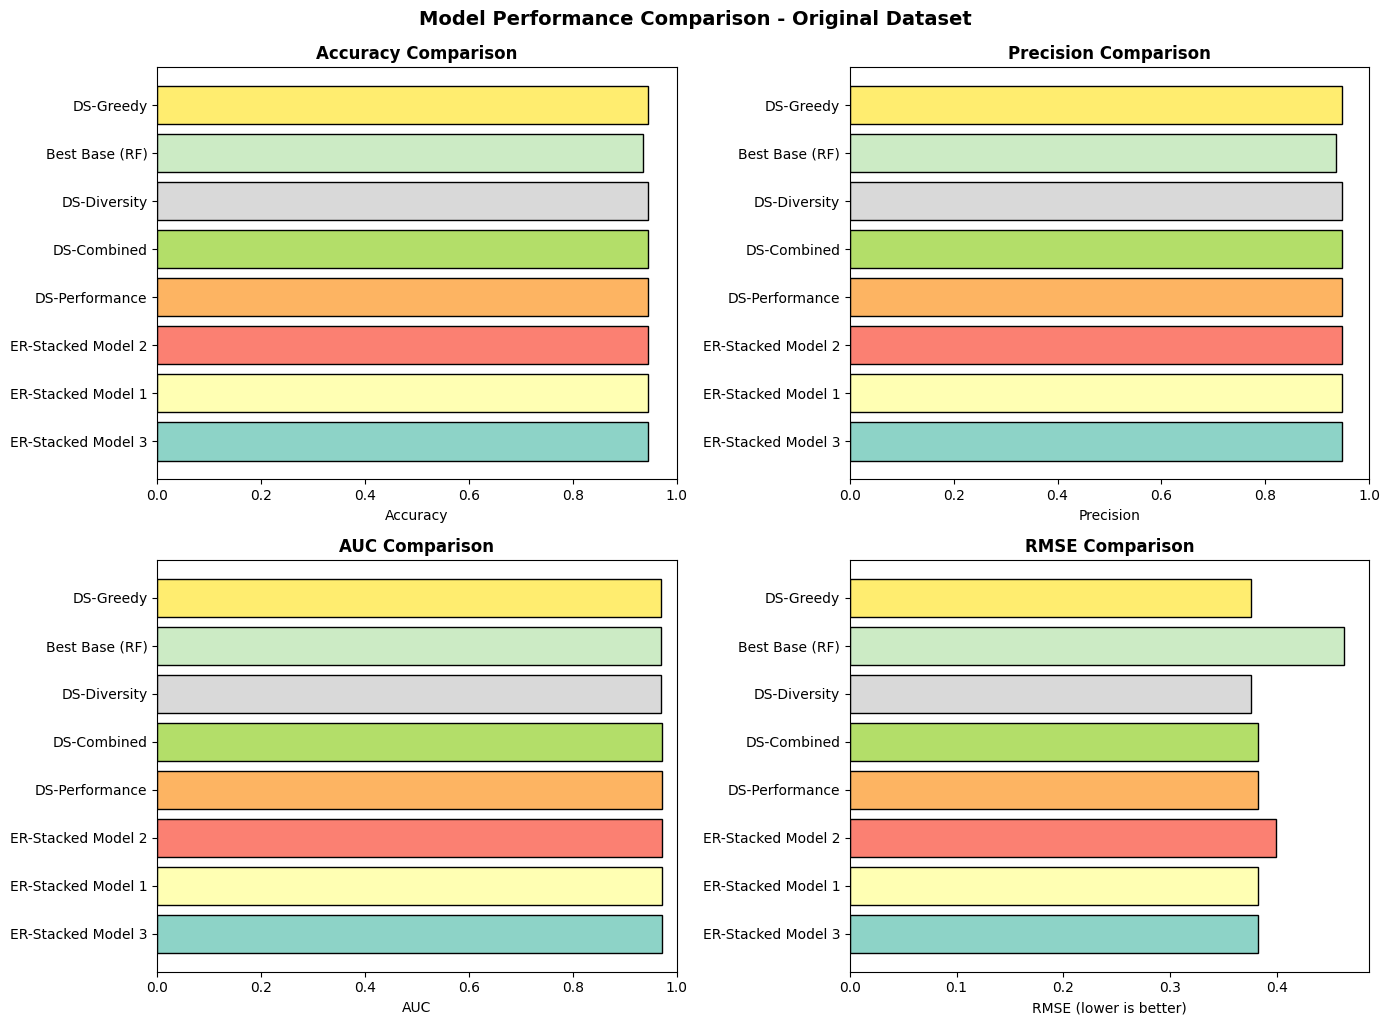

In [54]:
# Visualize final comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = final_comparison_df['Model'].tolist()
colors = plt.cm.Set3(np.linspace(0, 1, len(models)))

# Accuracy
ax1 = axes[0, 0]
accuracies = final_comparison_df['Accuracy'].tolist()
bars = ax1.barh(models, accuracies, color=colors, edgecolor='black')
ax1.set_xlabel('Accuracy')
ax1.set_title('Accuracy Comparison', fontweight='bold')
ax1.set_xlim(0, 1)

# Precision
ax2 = axes[0, 1]
precisions = final_comparison_df['Precision'].tolist()
bars = ax2.barh(models, precisions, color=colors, edgecolor='black')
ax2.set_xlabel('Precision')
ax2.set_title('Precision Comparison', fontweight='bold')
ax2.set_xlim(0, 1)

# AUC
ax3 = axes[1, 0]
aucs = final_comparison_df['AUC'].tolist()
bars = ax3.barh(models, aucs, color=colors, edgecolor='black')
ax3.set_xlabel('AUC')
ax3.set_title('AUC Comparison', fontweight='bold')
ax3.set_xlim(0, 1)

# RMSE (lower is better)
ax4 = axes[1, 1]
rmses = final_comparison_df['RMSE'].tolist()
bars = ax4.barh(models, rmses, color=colors, edgecolor='black')
ax4.set_xlabel('RMSE (lower is better)')
ax4.set_title('RMSE Comparison', fontweight='bold')

plt.tight_layout()
plt.suptitle('Model Performance Comparison - Original Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.show()

In [55]:
# Best model summary
print('\n' + '='*70)
print('BEST MODEL SUMMARY')
print('='*70)

best_model = final_comparison_df.iloc[0]
print(f"\nBest Performing Model: {best_model['Model']}")
print(f"  - Accuracy:  {best_model['Accuracy']:.4f} ({best_model['Accuracy']*100:.2f}%)")
print(f"  - Precision: {best_model['Precision']:.4f}")
print(f"  - AUC:       {best_model['AUC']:.4f}")
print(f"  - RMSE:      {best_model['RMSE']:.4f}")

print('\n' + '-'*70)
print('Top 3 Models:')
for i, row in final_comparison_df.head(3).iterrows():
    print(f"  {i+1}. {row['Model']}: Acc={row['Accuracy']:.4f}, AUC={row['AUC']:.4f}")


BEST MODEL SUMMARY

Best Performing Model: ER-Stacked Model 3
  - Accuracy:  0.9451 (94.51%)
  - Precision: 0.9476
  - AUC:       0.9725
  - RMSE:      0.3827

----------------------------------------------------------------------
Top 3 Models:
  1. ER-Stacked Model 3: Acc=0.9451, AUC=0.9725
  2. ER-Stacked Model 1: Acc=0.9451, AUC=0.9723
  3. ER-Stacked Model 2: Acc=0.9451, AUC=0.9716


---
## Phase 7: Explainability Analysis (XAI)

In [56]:
# Initialize XAI Explainer with best model
best_model_name = final_comparison_df.iloc[0]['Model']

# Get the best model
if 'ER-Stacked' in best_model_name:
    best_model_obj = er_models[best_model_name]
elif 'DS-' in best_model_name:
    best_model_obj = dynamic_stacks[best_model_name]
else:
    best_model_obj = base_clf.get_classifier(best_base)

# Feature names for this dataset
feature_names = ['Crankshaft', 'Overheating', 'Lubricant', 'Misfires', 'Piston', 'Starter']
class_names = ['Critical', 'Good', 'Minor', 'Moderate']

print(f'\nInitializing XAI for: {best_model_name}')
print(f'Features: {feature_names}')
print(f'Classes: {class_names}')


Initializing XAI for: ER-Stacked Model 3
Features: ['Crankshaft', 'Overheating', 'Lubricant', 'Misfires', 'Piston', 'Starter']
Classes: ['Critical', 'Good', 'Minor', 'Moderate']



Generating SHAP explanations...


<Figure size 1200x800 with 0 Axes>

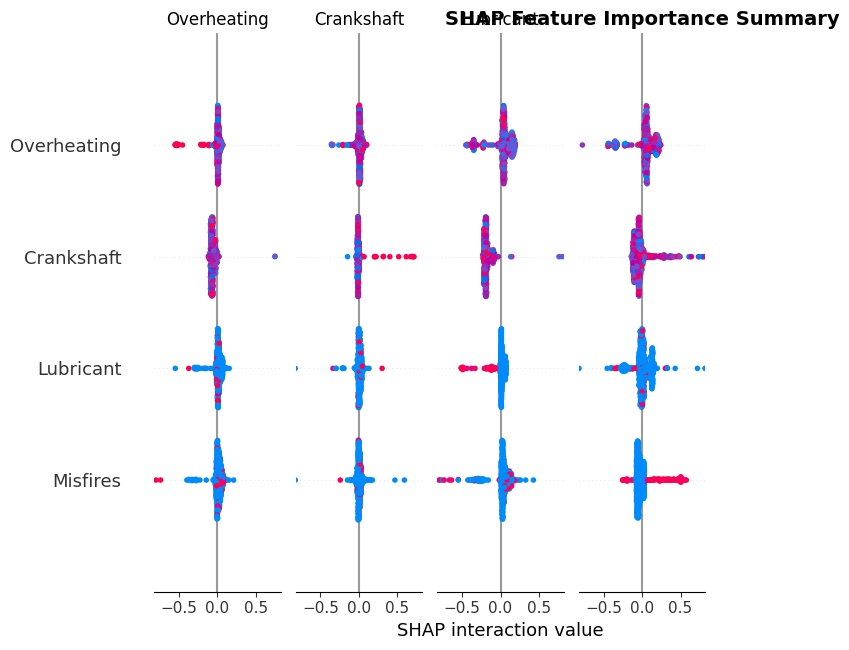

In [57]:
# SHAP Analysis using Random Forest (for tree-based explanation)
import shap

# Use RF model for SHAP (tree explainer works best with tree models)
rf_model = base_clf.get_classifier('RF')

print('\nGenerating SHAP explanations...')
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_names, 
                  class_names=class_names, show=False)
plt.title('SHAP Feature Importance Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

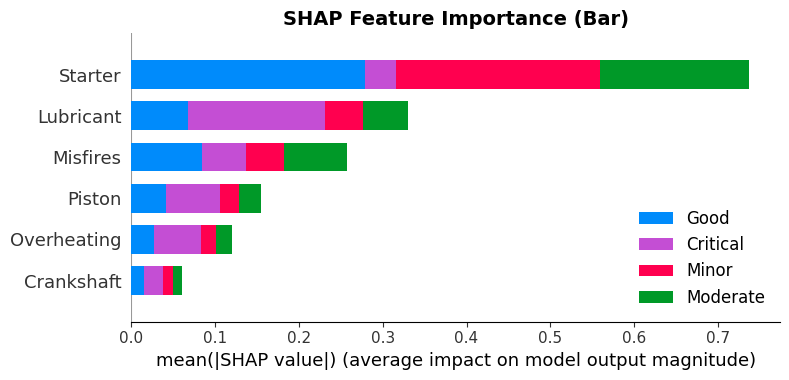

In [58]:
# Feature importance bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  plot_type='bar', class_names=class_names, show=False)
plt.title('SHAP Feature Importance (Bar)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Conclusion

### Key Findings from Original Dataset Analysis (cars1.csv)

1. **Dataset Characteristics**:
   - Original research dataset with 6 sensor features
   - No environmental variables (Temperature, Humidity, Altitude)
   - 4-class classification problem

2. **Base Classifier Performance**:
   - Individual classifiers provide baseline performance
   - Tree-based methods (RF, XGBoost) typically perform well

3. **Existing Research Stacked Ensembles**:
   - ER-Stacked Model 3 (all 9 classifiers) provides comprehensive coverage
   - Stacking improves over individual classifiers

4. **Dynamic Classifier Selection**:
   - Combined selection (performance + diversity) often yields best results
   - Greedy forward selection provides optimal subset

### Recommendations
- Use dynamic classifier selection for optimal ensemble composition
- Consider the trade-off between model complexity and performance
- The original dataset (without environmental features) still achieves good classification performance